# Regression Discontinuity Design (RDD)

## Scenario
The design of this example is inspired by Bermingham et al. (2021), but it is not a reproduction of their data or analysis. All numbers, values, and results are artificial and created solely to demonstrate the mechanics of Regression Discontinuity Design. Any resemblance to the published study’s results is coincidental and not intended to substitute for or replicate the original work.

Bermingham, C., Morgan, J., Ayoubkhani, D., Glickman, M., Islam, N., Sheikh, A., Sterne, J., Walker, A. S., & Nafilyan, V. (2023). Estimating the effectiveness of first dose of COVID-19 vaccine against mortality in England: A quasi-experimental study. American Journal of Epidemiology, 192(2), 267–275. https://doi.org/10.1093/aje/kwac157


## 1) Define the running variable and cutoff; build data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
np.random.seed(2025)

# -------------------------------------------------
# 1) Define the running variable and cutoff; build data
# -------------------------------------------------
# Synthetic population: ages 75–85 years
n = 20000
age_years = np.random.uniform(75, 85, size=n)
age_months = (age_years * 12).astype(int)
age = age_months / 12.0

# Running variable centered at 80 years (cutoff = 0)
running = age - 80.0
elig = (age >= 80.0).astype(int)  # eligibility indicator (instrument)

# Covariates
sex_male = np.random.binomial(1, 0.48, size=n)          # 1 = male
comorbidity = np.random.poisson(1.0, size=n)            # comorbidity index
imd = np.random.choice([1,2,3,4,5], size=n, 
                       p=[0.15,0.2,0.3,0.2,0.15])      # deprivation quintile

# Logistic helper
def logistic(x):
    return 1 / (1 + np.exp(-x))

# Vaccination probability: age slope + jump at cutoff
p_vax = logistic(-2.0 + 0.06 * running + 1.6 * elig 
                 - 0.05 * comorbidity + 0.12*(imd==5))
vaccinated = np.random.binomial(1, p_vax)

# Mortality probability: increases with age, comorbidity, IMD; reduced by vaccination
logodds_death = -4.0 + 0.25 * running + 0.9 * comorbidity + 0.35*(imd==5) - 1.2 * vaccinated
p_death = logistic(logodds_death)
death = np.random.binomial(1, p_death)

# Assemble dataframe and restrict window
df = pd.DataFrame({
    "age_years": age,
    "running": running,
    "elig": elig,
    "vaccinated": vaccinated,
    "p_vax": p_vax,
    "death": death,
    "p_death": p_death,
    "sex_male": sex_male,
    "comorbidity": comorbidity,
    "imd": imd
})

# Keep analysis window 75–85 years
df_rd = df[(df["age_years"] >= 75) & (df["age_years"] <= 85)].copy()
df_rd["running_sq"] = df_rd["running"] ** 2
df_rd.describe()

,age_years,running,elig,vaccinated,p_vax,death,p_death,sex_male,comorbidity,imd,running_sq
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,79.959288,-0.040713,0.49835,0.265100,0.264943,0.059200,0.059787,0.480350,1.011400,3.002000,8.249045
std,2.871898,2.871898,0.50001,0.441397,0.165103,0.236005,0.085258,0.499626,1.001759,1.256971,7.440040
min,75.000000,-5.000000,0.00000,0.000000,0.072426,0.000000,0.001578,0.000000,0.000000,1.000000,0.000000
25%,77.500000,-2.500000,0.00000,0.000000,0.101106,0.000000,0.014653,0.000000,0.000000,2.000000,1.562500
50%,79.916667,-0.083333,0.00000,0.000000,0.130108,0.000000,0.030769,0.000000,1.000000,3.000000,6.250000
75%,82.416667,2.416667,1.00000,1.000000,0.429228,0.000000,0.067810,1.000000,2.000000,4.000000,14.062500
max,84.916667,4.916667,1.00000,1.000000,0.503750,1.000000,0.936780,1.000000,7.000000,5.000000,25.000000


## 2) LATE

### (2.1) First-stage


In [22]:
# -------------------------------------------------
# 2) Determine sharp vs fuzzy RDD: First-stage strength
# -------------------------------------------------
X_fs = sm.add_constant(df_rd[["elig", "running", "running_sq"]])
fs_model = sm.OLS(df_rd["vaccinated"], X_fs).fit(cov_type="HC1")
df_rd["vax_hat"] = fs_model.predict(X_fs)
print(fs_model.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1210      0.006     21.546      0.000       0.110       0.132
elig           0.2817      0.012     24.387      0.000       0.259       0.304
running        0.0098      0.002      4.876      0.000       0.006       0.014
running_sq     0.0005      0.000      1.274      0.203      -0.000       0.001


### (2.2) Reduced-form OLS

In [20]:
X_rf = sm.add_constant(df_rd[["elig", "running", "running_sq"]])
rf_model = sm.OLS(df_rd["death"], X_rf).fit(cov_type="HC1")
print(rf_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  death   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     87.54
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           2.85e-56
Time:                        23:24:14   Log-Likelihood:                 646.51
No. Observations:               20000   AIC:                            -1285.
Df Residuals:                   19996   BIC:                            -1253.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0552      0.004     15.446      0.0

## 3) Bandwidth selection (automatic + sensitivity)

In [4]:
# Candidate grid for bandwidths
h_grid = np.linspace(0.2, 2.0, 19)

### (3.1) IK

In [5]:
# IK bandwidth (simple plug-in via global poly)
def ik_bandwidth(running, outcome):
    n = len(running)
    X_poly = np.column_stack([running, running**2, running**3])
    X_poly = sm.add_constant(X_poly)
    model_poly = sm.OLS(outcome, X_poly).fit()
    second_deriv = 2 * model_poly.params[2]
    sigma2 = np.var(model_poly.resid)
    C = (720 * sigma2) / (n * (second_deriv**2 + 1e-12))
    h_ik = max(C, 1e-12)**(1/5)
    return h_ik

h_ik = ik_bandwidth(df_rd["running"].values, df_rd["death"].values)
print(f"IK bandwidth: {h_ik:.3f} years")

IK bandwidth: 3.561 years


### (3.2) CV

In [6]:
# CV bandwidth (leave-one-out OLS on reduced-form within candidate h)
def cv_bandwidth(data, outcome, regressors, h_grid):
    best_h = h_grid[0]
    min_mse = np.inf
    for h in h_grid:
        subset = data[np.abs(data["running"]) <= h].copy()
        n_subset = len(subset)
        if n_subset < 50:
            continue
        X = sm.add_constant(subset[regressors], has_constant='add')
        mse = 0.0
        for i in range(n_subset):
            X_loo = np.delete(X.values, i, axis=0)
            y_loo = np.delete(subset[outcome].values, i)
            model = sm.OLS(y_loo, X_loo).fit()
            y_hat_i = model.predict(X.values[i:i+1])
            mse += (subset[outcome].values[i] - y_hat_i[0])**2
        mse /= n_subset
        if mse < min_mse:
            min_mse = mse
            best_h = h
    return best_h

h_cv = cv_bandwidth(df_rd, outcome="death", regressors=["elig", "running", "running_sq"], h_grid=h_grid)
print(f"CV bandwidth: {h_cv:.3f} years")

CV bandwidth: 0.200 years


### (3.3) CCT

In [7]:
def triangular_weights(x, h, cutoff=0.0):
    d = np.abs(x - cutoff)
    w = np.clip(1.0 - d / h, 0.0, 1.0)
    w[d > h] = 0.0
    return w

# Unweighted local linear (for display / baseline)
def local_linear_ols(data, outcome, regressors, h, cutoff=0.0):
    subset = data[np.abs(data["running"] - cutoff) <= h].copy()
    if len(subset) < 30:
        return np.nan, np.nan, 0, None
    X = sm.add_constant(subset[regressors], has_constant='add')
    model = sm.OLS(subset[outcome], X).fit(cov_type="HC1")
    return model.params, model.bse, len(subset), model

# Weighted local linear RD with triangular kernel

# Some bins or age groups might have more individuals than others.
# They weighted the regression by **group counts** to give more influence to larger bins and make estimates more representative.

def local_linear_wls(data, outcome, h, cutoff=0.0, include_quad=False, treatment_name="elig"):
    subset = data[np.abs(data["running"] - cutoff) <= h].copy()
    if len(subset) < 30:
        return np.nan, np.nan, 0, None
    subset["x"] = subset["running"] - cutoff
    cols = ["x", treatment_name]
    if include_quad:
        subset["x2"] = subset["x"]**2
        cols.append("x2")
    X = sm.add_constant(subset[cols], has_constant='add')
    w = triangular_weights(subset["running"].values, h, cutoff)
    model = sm.WLS(subset[outcome], X, weights=w).fit(cov_type="HC1")
    tau = model.params[treatment_name]
    se_tau = model.bse[treatment_name]
    n_eff = w.sum()
    return tau, se_tau, n_eff, model

# Second derivatives via local quadratic WLS on each side
def second_derivatives_wls(data, outcome, h, cutoff=0.0):
    subset = data[np.abs(data["running"] - cutoff) <= h].copy()
    subset["x"] = subset["running"] - cutoff

    # Left
    left = subset[subset["x"] < 0].copy()
    d2_left = 0.0
    if len(left) >= 20:
        Xl = sm.add_constant(np.column_stack([left["x"].values, left["x"].values**2]))
        wl = triangular_weights(left["running"].values, h, cutoff)
        ml = sm.WLS(left[outcome].values, Xl, weights=wl).fit()
        d2_left = 2.0 * ml.params[2]

    # Right
    right = subset[subset["x"] >= 0].copy()
    d2_right = 0.0
    if len(right) >= 20:
        Xr = sm.add_constant(np.column_stack([right["x"].values, right["x"].values**2]))
        wr = triangular_weights(right["running"].values, h, cutoff)
        mr = sm.WLS(right[outcome].values, Xr, weights=wr).fit()
        d2_right = 2.0 * mr.params[2]

    Delta = d2_right - d2_left
    return d2_left, d2_right, Delta

# CCT-style bandwidth via AMSE(h) ≈ sigma^2/(n_eff h) + ((Delta/2)^2) h^4
def cct_bandwidth(data, outcome, h_grid, cutoff=0.0):
    best_h, best_obj = h_grid[0], np.inf
    for h in h_grid:
        subset = data[np.abs(data["running"] - cutoff) <= h].copy()
        if len(subset) < 50:
            continue
        tau_ll, se_ll, n_eff, m_ll = local_linear_wls(data, outcome=outcome, h=h, cutoff=cutoff, include_quad=False, treatment_name="elig")
        if m_ll is None:
            continue
        resid = m_ll.resid
        w = triangular_weights(subset["running"].values, h, cutoff)
        sigma2 = np.average(resid**2, weights=w)
        _, _, Delta = second_derivatives_wls(data, outcome=outcome, h=h, cutoff=cutoff)
        var_term = sigma2 / max(n_eff * h, 1e-8)
        bias_term_sq = (Delta**2 / 4.0) * (h**4)
        obj = var_term + bias_term_sq
        if obj < best_obj:
            best_obj = obj
            best_h = h
    return best_h

h_cct = cct_bandwidth(df_rd, outcome="death", h_grid=h_grid, cutoff=0.0)
print(f"CCT bandwidth: {h_cct:.3f} years")

CCT bandwidth: 0.800 years


## 4) Robust Bias-Corrected (RBC)

In [40]:
# RBC estimate for reduced-form or first-stage
def rbc_estimate(data, outcome, h, cutoff=0.0):
    tau_ll, se_ll, n_eff, _ = local_linear_wls(data, outcome=outcome, h=h, cutoff=cutoff, include_quad=False, treatment_name="elig")
    _, _, Delta = second_derivatives_wls(data, outcome=outcome, h=h, cutoff=cutoff)
    bias_hat = (Delta / 2.0) * (h**2)
    tau_rbc = tau_ll - bias_hat
    return tau_rbc, tau_ll, se_ll, n_eff, bias_hat

In [41]:
# Local linear WLS estimates at chosen CCT bandwidth
rf_tau_rbc, rf_tau_ll, rf_se_ll, rf_n_eff, rf_bias_hat = rbc_estimate(df_rd, outcome="death", h=h_cct)
fs_tau_rbc, fs_tau_ll, fs_se_ll, fs_n_eff, fs_bias_hat = rbc_estimate(df_rd, outcome="vaccinated", h=h_cct)

# LATE via Wald using LL estimates (and RBC variant)
wald_late_ll = rf_tau_ll / fs_tau_ll if fs_tau_ll != 0 else np.nan
wald_late_rbc = rf_tau_rbc / fs_tau_rbc if fs_tau_rbc != 0 else np.nan

# Put in a table
rows = [{
        "Component": "Reduced-form (elig → death)",
        "LL τ": rf_tau_ll,
        "SE": rf_se_ll,
        "Biaŝ": rf_bias_hat,
        "RBC τ": rf_tau_rbc,
        "n_eff": int(round(rf_n_eff))},
    {   "Component": "First-stage (elig → vaccinated)",
        "LL τ": fs_tau_ll,
        "SE": fs_se_ll,
        "Biaŝ": fs_bias_hat,
        "RBC τ": fs_tau_rbc,
        "n_eff": int(round(fs_n_eff)) }]
tbl = pd.DataFrame(rows)
display(tbl)

,Component,LL τ,SE,Biaŝ,RBC τ,n_eff
0,Reduced-form (elig → death),-0.037161,0.015089,-0.008943,-0.028217,1655
1,First-stage (elig → vaccinated),0.333877,0.032300,-0.065681,0.399558,1655


In [39]:
# Add Wald LATEs as a separate small table or append footnote text
wald_tbl = pd.DataFrame({
    "Estimator": ["Wald LATE (LL)", "Wald LATE (RBC)"],
    "Value": [wald_late_ll, wald_late_rbc]  })
display(wald_tbl)

,Estimator,Value
0,Wald LATE (LL),-0.111301
1,Wald LATE (RBC),-0.070622


## 5) Visualization 

### (5.1) Treatment Effect (First-stage)

/var/folders/b8/hq7p21n142n321y966q8j1600000gn/T/ipykernel_51717/3779132428.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y.groupby(b).mean()


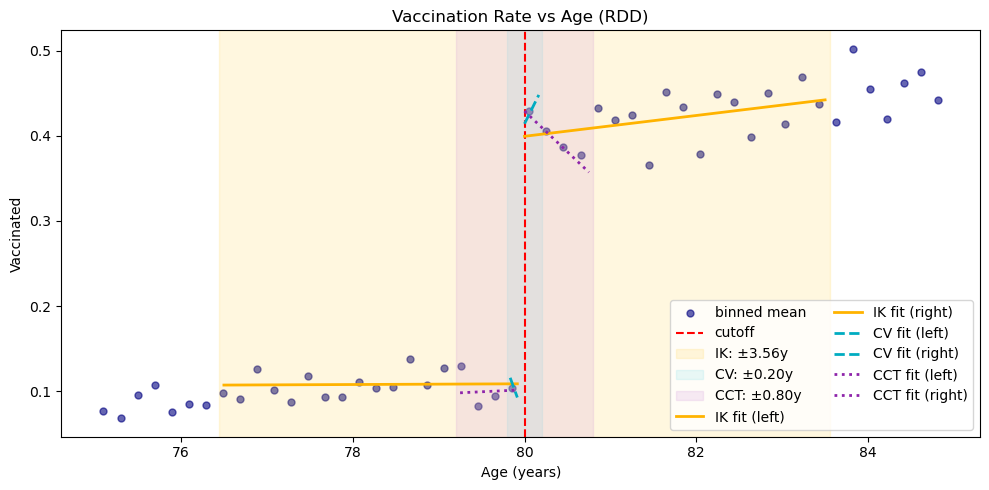

In [11]:
# -------------------------------------------------
# Fitted lines: local linear WLS on each side for a given bandwidth
# -------------------------------------------------
def fit_lines_for_bandwidth(ax, data, outcome, h, cutoff=0.0, color="#333", linestyle="-", label_prefix=""):
    subset = data[np.abs(data["running"] - cutoff) <= h].copy()
    subset["x"] = subset["running"] - cutoff

    # Left side
    left = subset[subset["x"] < 0].copy()
    if len(left) >= 20:
        Xl = sm.add_constant(left[["x"]])
        wl = triangular_weights(left["running"].values, h, cutoff)
        ml = sm.WLS(left[outcome].values, Xl, weights=wl).fit()
        left_sorted = left.sort_values("age_years")
        Xl_pred = sm.add_constant(left_sorted[["x"]])
        yl_pred = ml.predict(Xl_pred)
        ax.plot(left_sorted["age_years"], yl_pred, color=color, linestyle=linestyle, linewidth=2,
                label=f"{label_prefix} fit (left)")

    # Right side
    right = subset[subset["x"] >= 0].copy()
    if len(right) >= 20:
        Xr = sm.add_constant(right[["x"]])
        wr = triangular_weights(right["running"].values, h, cutoff)
        mr = sm.WLS(right[outcome].values, Xr, weights=wr).fit()
        right_sorted = right.sort_values("age_years")
        Xr_pred = sm.add_constant(right_sorted[["x"]])
        yr_pred = mr.predict(Xr_pred)
        ax.plot(right_sorted["age_years"], yr_pred, color=color, linestyle=linestyle, linewidth=2,
                label=f"{label_prefix} fit (right)")

# -------------------------------------------------
# Helper for binned scatter (visual guide)
# -------------------------------------------------
def binned_scatter(ax, x, y, bins=50, label="binned mean", color="black"):
    b = pd.cut(x, bins=bins)
    means = y.groupby(b).mean()
    centers = pd.Series([interval.mid for interval in means.index])
    ax.scatter(centers, means.values, s=25, color=color, alpha=0.6, label=label)

# -------------------------------------------------
# Figure 1: Vaccination Rate vs Age 
# -------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 5))

# Scatter + binned means
#ax1.scatter(df_rd["age_years"], df_rd["vaccinated"], alpha=0.05, color="#1f77b4", label="data")
binned_scatter(ax1, df_rd["age_years"], df_rd["vaccinated"], bins=50, label="binned mean", color="navy")

# Cutoff and shaded bandwidths
ax1.axvline(80.0, color="red", linestyle="--", label="cutoff")
ax1.axvspan(80.0 - h_ik,  80.0 + h_ik,  color="#ffd54f", alpha=0.18, label=f"IK: ±{h_ik:.2f}y")
ax1.axvspan(80.0 - h_cv,  80.0 + h_cv,  color="#80deea", alpha=0.18, label=f"CV: ±{h_cv:.2f}y")
ax1.axvspan(80.0 - h_cct, 80.0 + h_cct, color="#ce93d8", alpha=0.18, label=f"CCT: ±{h_cct:.2f}y")

# Fitted lines for each bandwidth
fit_lines_for_bandwidth(ax1, df_rd, outcome="vaccinated", h=h_ik,  color="#ffb300", linestyle="-",  label_prefix="IK")
fit_lines_for_bandwidth(ax1, df_rd, outcome="vaccinated", h=h_cv,  color="#00acc1", linestyle="--", label_prefix="CV")
fit_lines_for_bandwidth(ax1, df_rd, outcome="vaccinated", h=h_cct, color="#8e24aa", linestyle=":",  label_prefix="CCT")

ax1.set_title("Vaccination Rate vs Age (RDD)")
ax1.set_xlabel("Age (years)")
ax1.set_ylabel("Vaccinated")
ax1.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()
# fig1.savefig("vaccination_three_bandwidths_fits.png", dpi=160)  # optional


### (5.2) Output vs. Running Variable (Reduced-form)

/var/folders/b8/hq7p21n142n321y966q8j1600000gn/T/ipykernel_51717/3779132428.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = y.groupby(b).mean()


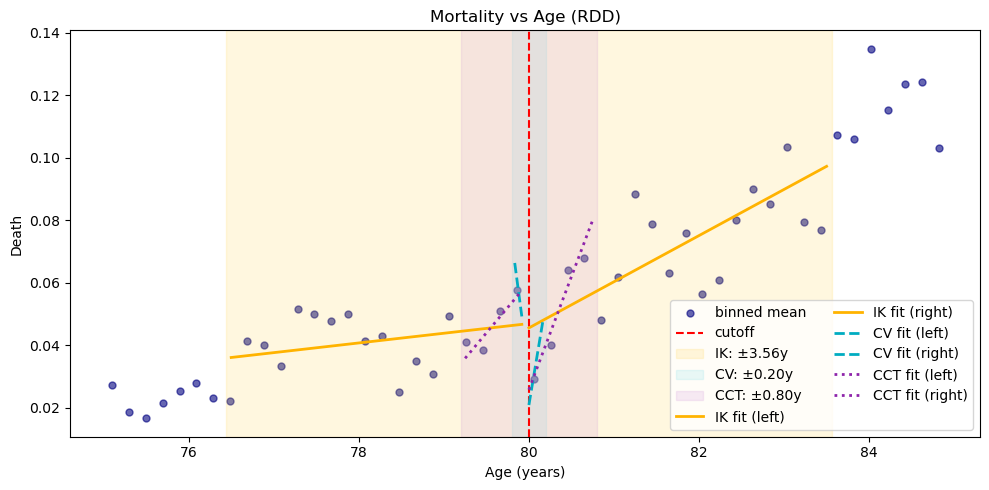

In [12]:
# -------------------------------------------------
# Figure 2: Mortality vs Age 
# -------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 5))

# Scatter + binned means
binned_scatter(ax2, df_rd["age_years"], df_rd["death"], bins=50, label="binned mean", color="navy")

# Cutoff and shaded bandwidths
ax2.axvline(80.0, color="red", linestyle="--", label="cutoff")
ax2.axvspan(80.0 - h_ik,  80.0 + h_ik,  color="#ffd54f", alpha=0.18, label=f"IK: ±{h_ik:.2f}y")
ax2.axvspan(80.0 - h_cv,  80.0 + h_cv,  color="#80deea", alpha=0.18, label=f"CV: ±{h_cv:.2f}y")
ax2.axvspan(80.0 - h_cct, 80.0 + h_cct, color="#ce93d8", alpha=0.18, label=f"CCT: ±{h_cct:.2f}y")

# Fitted lines for each bandwidth
fit_lines_for_bandwidth(ax2, df_rd, outcome="death", h=h_ik,  color="#ffb300", linestyle="-",  label_prefix="IK")
fit_lines_for_bandwidth(ax2, df_rd, outcome="death", h=h_cv,  color="#00acc1", linestyle="--", label_prefix="CV")
fit_lines_for_bandwidth(ax2, df_rd, outcome="death", h=h_cct, color="#8e24aa", linestyle=":",  label_prefix="CCT")

ax2.set_title("Mortality vs Age (RDD)")
ax2.set_xlabel("Age (years)")
ax2.set_ylabel("Death")
ax2.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()
# fig2.savefig("mortality_three_bandwidths_fits.png", dpi=160)  # optional


## 6) Sensitivity analyses

### (6.1) Placebo discontinuity tests for Covariates

In [25]:
# Falsification checks: RD on covariates at CCT bandwidth
covariates = ["sex_male", "comorbidity", "imd"]
placebo_results = []
for cov in covariates:
    tau_cov, se_cov, n_eff_cov, _ = local_linear_wls(df_rd, outcome=cov, h=h_cct, cutoff=0.0, include_quad=False, treatment_name="elig")
    t_stat = tau_cov / se_cov if se_cov not in [0, np.nan] else np.nan
    p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=int(max(n_eff_cov - 3, 1)))) if not np.isnan(t_stat) else np.nan
    placebo_results.append({
        "Covariate": cov,
        "Tau": tau_cov,
        "SE": se_cov,
        "n_eff": n_eff_cov,
        "p_value": p_val
    })
placebo_df = pd.DataFrame(placebo_results)
print("\n=== Placebo discontinuities in covariates at cutoff (CCT bandwidth) ===")
print(placebo_df.round(4))


=== Placebo discontinuities in covariates at cutoff (CCT bandwidth) ===
     Covariate     Tau      SE      n_eff  p_value
0     sex_male -0.0057  0.0384  1654.6042   0.8819
1  comorbidity -0.0330  0.0807  1654.6042   0.6831
2          imd -0.0491  0.0922  1654.6042   0.5943


### (6.2) Sensitivity analyses across bandwidths

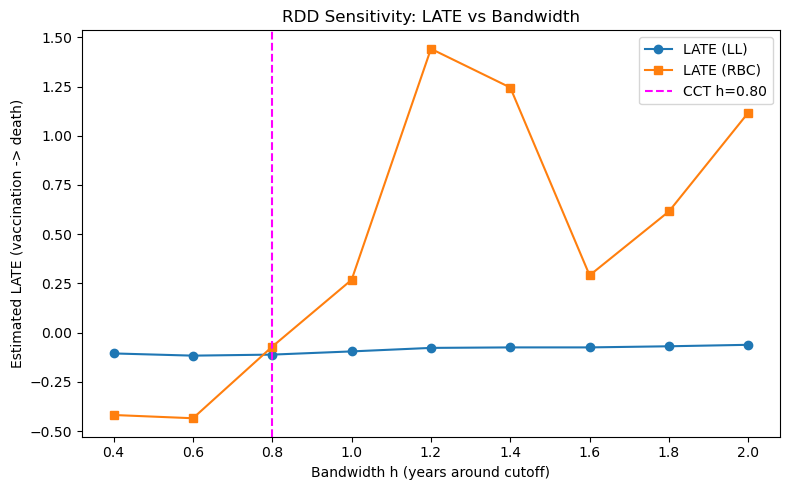

In [29]:
results_sens = []
for h in np.linspace(0.4, 2.0, 9):
    rf_tau_rbc_h, rf_tau_ll_h, rf_se_ll_h, rf_n_eff_h, rf_bias_h = rbc_estimate(df_rd, outcome="death", h=h)
    fs_tau_rbc_h, fs_tau_ll_h, fs_se_ll_h, fs_n_eff_h, fs_bias_h = rbc_estimate(df_rd, outcome="vaccinated", h=h)
    late_ll_h = rf_tau_ll_h / fs_tau_ll_h if fs_tau_ll_h != 0 else np.nan
    late_rbc_h = rf_tau_rbc_h / fs_tau_rbc_h if fs_tau_rbc_h != 0 else np.nan
    results_sens.append({
        "h": h,
        "RF_LL": rf_tau_ll_h,
        "RF_RBC": rf_tau_rbc_h,
        "FS_LL": fs_tau_ll_h,
        "FS_RBC": fs_tau_rbc_h,
        "LATE_LL": late_ll_h,
        "LATE_RBC": late_rbc_h,
        "RF_bias_hat": rf_bias_h,
        "FS_bias_hat": fs_bias_h,
        "n_eff_RF": rf_n_eff_h,
        "n_eff_FS": fs_n_eff_h
    })

sens_df = pd.DataFrame(results_sens)

fig2, ax2 = plt.subplots(1, 1, figsize=(8, 5))
ax2.plot(sens_df["h"], sens_df["LATE_LL"], marker='o', label="LATE (LL)")
ax2.plot(sens_df["h"], sens_df["LATE_RBC"], marker='s', label="LATE (RBC)")
ax2.axvline(h_cct, color='magenta', linestyle='--', label=f"CCT h={h_cct:.2f}")
ax2.set_xlabel("Bandwidth h (years around cutoff)")
ax2.set_ylabel("Estimated LATE (vaccination -> death)")
ax2.set_title("RDD Sensitivity: LATE vs Bandwidth")
ax2.legend()
plt.tight_layout()
plt.show()